# Comprehensive Exploratory Data Analysis (EDA) - LaunchSignal
This notebook walks through the entire EDA process for the LaunchSignal IPO Predictor project. 
It covers everything from reading the raw dataset, inspecting its structure, checking for missing values, and visualizing the data distributions to understand the features that drive IPO listing gains.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

## 1. Data Loading and Basic Inspection
First, we load the dataset and take a look at the first few rows to understand the features.

In [3]:
# Load the dataset
df = pd.read_csv('data.csv')

# Display the first 5 rows
display(df.head())

,company,gmp,retail_sub,qib_sub,nii_sub,issue_size,sector,market_trend,listing_return
0,Paytm,-10.0,1.66,2.79,1.97,18300.0,Fintech,-0.5,-27.4
1,Zomato,12.0,38.25,51.79,33.49,9375.0,Food Tech,1.2,66.0
2,Nykaa,60.0,12.24,91.49,111.88,5352.0,E-commerce,0.8,78.0
3,CarTrade,35.0,20.29,4.76,1.01,2999.0,Auto Tech,0.5,-8.0
4,Devyani International,45.0,113.94,100.77,32.16,1838.0,Food,1.0,56.3


Let's check the shape of the dataset and the data types of our columns.

In [4]:
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns\n")
df.info()

Dataset Shape: 468 rows and 9 columns

<class 'pandas.DataFrame'>
RangeIndex: 468 entries, 0 to 467
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   company         468 non-null    str    
 1   gmp             468 non-null    float64
 2   retail_sub      468 non-null    float64
 3   qib_sub         468 non-null    float64
 4   nii_sub         468 non-null    float64
 5   issue_size      468 non-null    float64
 6   sector          468 non-null    str    
 7   market_trend    468 non-null    float64
 8   listing_return  468 non-null    float64
dtypes: float64(7), str(2)
memory usage: 44.0 KB


## 2. Data Cleaning & Missing Values Check
It's crucial to ensure our dataset has no missing values or duplicates before feeding it to a machine learning model.

In [5]:
# Check for missing values
print("Missing Values per Column:")
display(df.isnull().sum())

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nTotal duplicate rows: {duplicates}")

Missing Values per Column:


company           0
gmp               0
retail_sub        0
qib_sub           0
nii_sub           0
issue_size        0
sector            0
market_trend      0
listing_return    0
dtype: int64


Total duplicate rows: 0


## 3. Descriptive Statistics
Let's compute the summary statistics for the numerical features to understand their central tendencies and spread.

In [6]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
gmp,468.0,32.422778,186.843474,-1595.71,-6.3750,24.200,75.00,1227.26
retail_sub,468.0,27.060556,50.012422,0.00,1.7800,5.960,24.39,326.49
qib_sub,468.0,38.374444,53.423120,0.00,2.0100,12.690,57.14,321.59
nii_sub,468.0,61.148312,113.384260,0.00,1.5900,11.690,82.00,958.07
issue_size,468.0,1565.726090,2990.440467,0.00,291.1700,600.000,1248.75,21000.00
market_trend,468.0,0.939744,0.181008,-0.50,1.0000,1.000,1.00,1.20
listing_return,468.0,14.731111,46.802419,-97.15,-7.8725,9.975,37.10,270.40


## 4. Univariate Analysis (Distributions)
We will visualize the distribution of our core features using Histograms and Kernel Density Estimates (KDE). This helps us understand if the data is skewed.

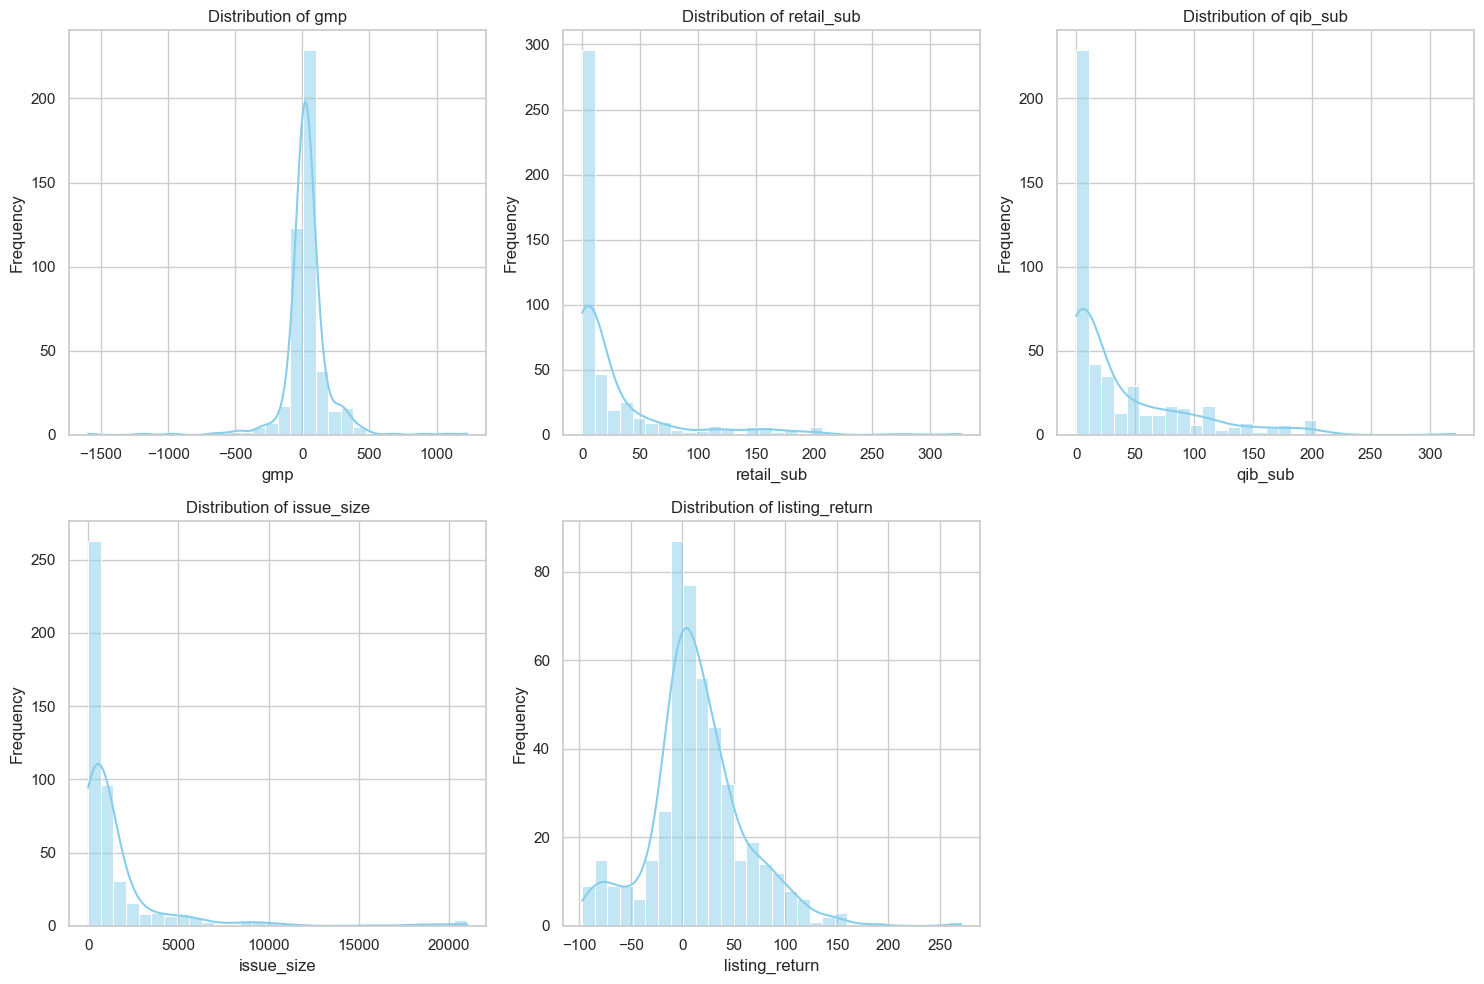

In [7]:
features_to_plot = ['gmp', 'retail_sub', 'qib_sub', 'issue_size', 'listing_return']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[feature], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## 5. Outlier Detection
Financial data often contains extreme values (like massive oversubscriptions). Boxplots are great for spotting these outliers.

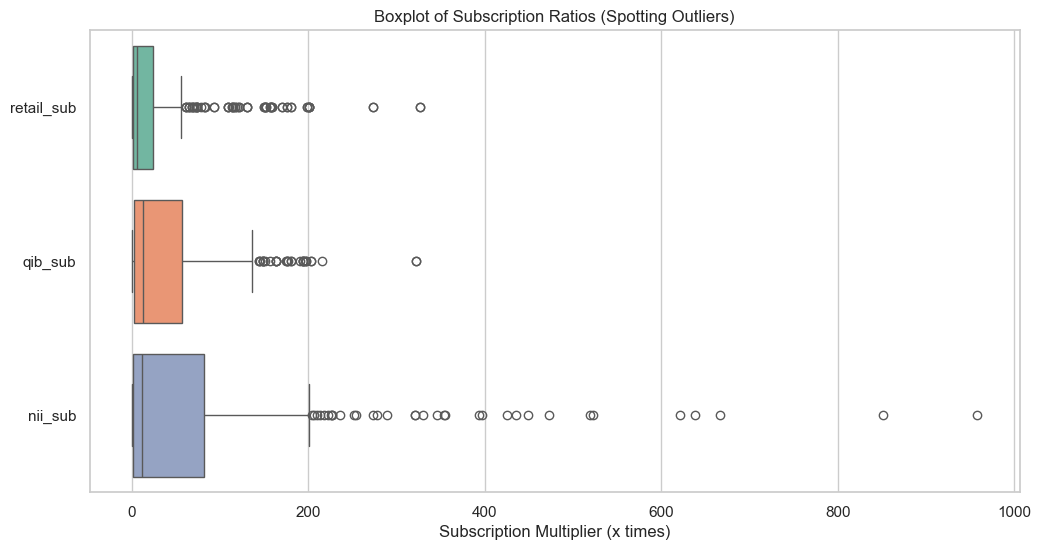

In [8]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['retail_sub', 'qib_sub', 'nii_sub']], orient="h", palette="Set2")
plt.title("Boxplot of Subscription Ratios (Spotting Outliers)")
plt.xlabel("Subscription Multiplier (x times)")
plt.show()

## 6. Target Variable Analysis: Profit vs Loss
How risky are IPOs? Let's look at the percentage of IPOs that listed at a premium (profit) versus a discount (loss).

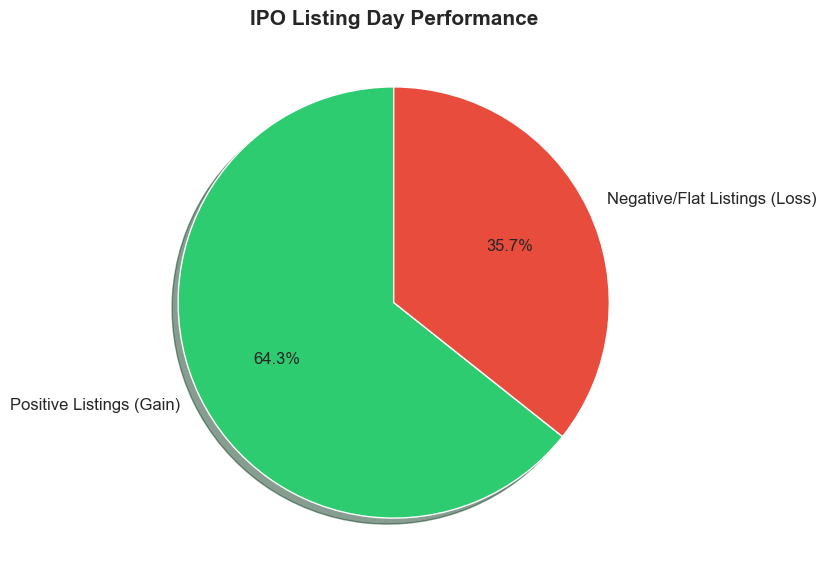

In [9]:
plt.figure(figsize=(7, 7))
pos = len(df[df['listing_return'] > 0])
neg = len(df[df['listing_return'] <= 0])

plt.pie([pos, neg], labels=['Positive Listings (Gain)', 'Negative/Flat Listings (Loss)'], 
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90, textprops={'fontsize': 12}, shadow=True)
plt.title('IPO Listing Day Performance', fontsize=15, fontweight='bold')
plt.show()

## 7. Bivariate Analysis: Features vs Target
Let's see how our most important features relate directly to the target variable (`listing_return`).

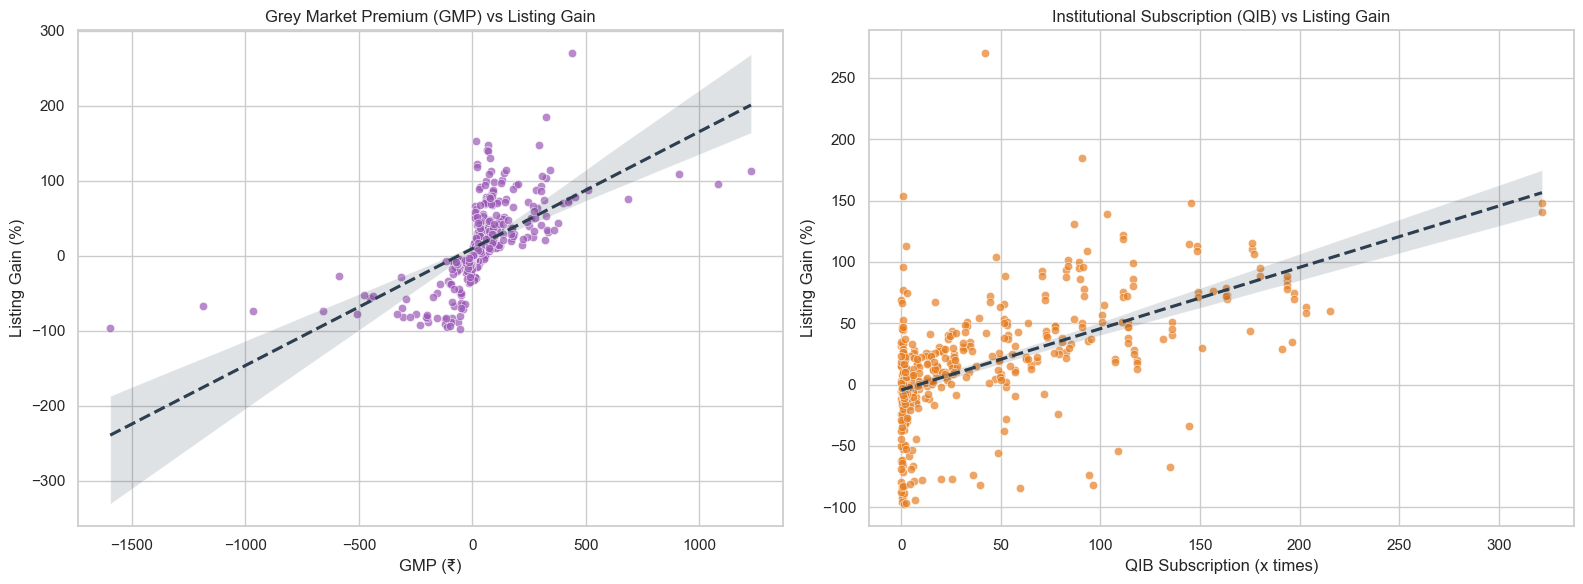

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# GMP vs Listing Return
sns.scatterplot(data=df, x='gmp', y='listing_return', alpha=0.7, color='#9b59b6', ax=axes[0])
sns.regplot(data=df, x='gmp', y='listing_return', scatter=False, color='#2c3e50', line_kws={"linestyle":"--"}, ax=axes[0])
axes[0].set_title('Grey Market Premium (GMP) vs Listing Gain')
axes[0].set_xlabel('GMP (₹)')
axes[0].set_ylabel('Listing Gain (%)')

# QIB Sub vs Listing Return
sns.scatterplot(data=df, x='qib_sub', y='listing_return', alpha=0.7, color='#e67e22', ax=axes[1])
sns.regplot(data=df, x='qib_sub', y='listing_return', scatter=False, color='#2c3e50', line_kws={"linestyle":"--"}, ax=axes[1])
axes[1].set_title('Institutional Subscription (QIB) vs Listing Gain')
axes[1].set_xlabel('QIB Subscription (x times)')
axes[1].set_ylabel('Listing Gain (%)')

plt.tight_layout()
plt.show()

## 8. Correlation Analysis
Finally, we compute the Pearson Correlation Matrix to quantify the linear relationships between all numerical features and the listing return.

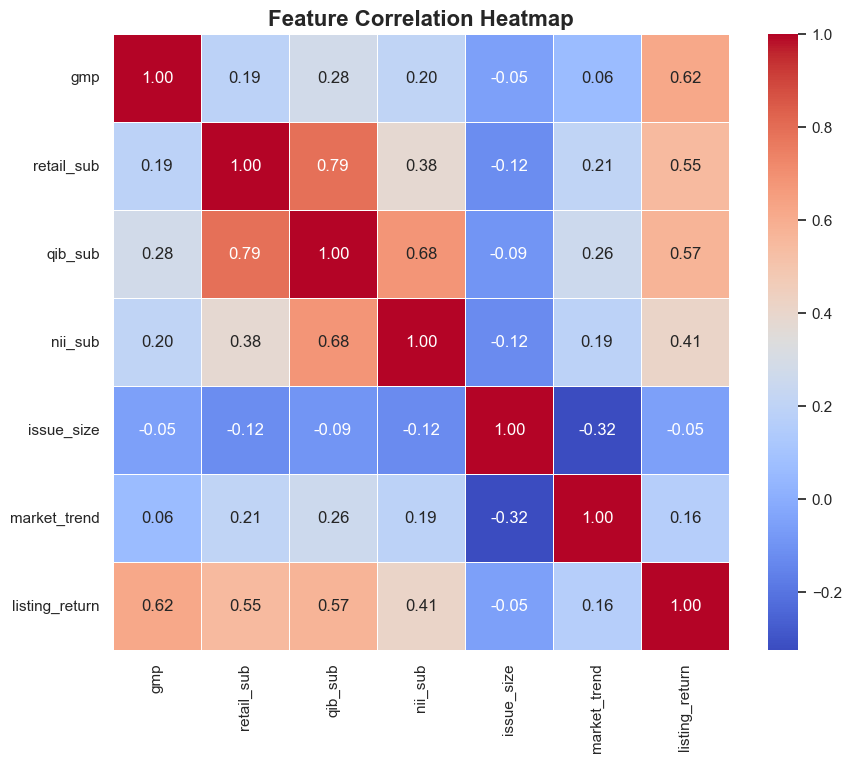

In [11]:
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.show()

Let's isolate the target variable to rank the predictive power of each feature.

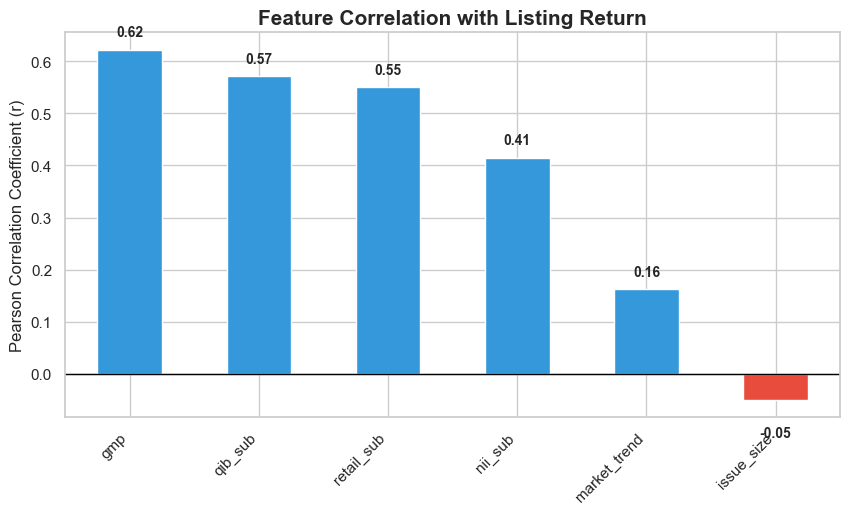

In [12]:
plt.figure(figsize=(10, 5))
corrs = corr_matrix['listing_return'].sort_values(ascending=False).drop('listing_return')
colors = ['#3498db' if c > 0 else '#e74c3c' for c in corrs.values]

ax = corrs.plot(kind='bar', color=colors)
plt.title('Feature Correlation with Listing Return', fontsize=15, fontweight='bold')
plt.ylabel('Pearson Correlation Coefficient (r)')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=1)

for i, v in enumerate(corrs.values):
    ax.text(i, v + (0.02 if v > 0 else -0.05), f'{v:.2f}', ha='center', va='bottom' if v > 0 else 'top', fontsize=10, fontweight='bold')
plt.show()